# 05 - PPO Training (Dynamic 1-10 Node Cluster Generalization + CUDA)

This notebook trains the generalized PPO scheduler with:
1. **Dynamic Cluster Topologies ($1$ to $10$ nodes)**: Randomized node counts and heterogeneous GPU combinations on every reset with slot padding ($N_{\max} = 10$).
2. **Vectorized Multi-Scenario Domain Randomization**: $N=8$ parallel environments training across all $6$ benchmark scenarios simultaneously.
3. **Proactive Future Arrival Lookahead**: 7 global cluster state & arrival countdown hint features.
4. **Strict Logit-Level Action Masking**: $-\infty$ logit masking on invalid node placements and padded/absent node slots.
5. **Full GPU Tensor Acceleration**: Batched backpropagation on CUDA (`NVIDIA GeForce RTX 3050 Laptop GPU`).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

# Ensure project root is in python path
sys.path.insert(0, os.path.abspath('..'))

from rl.config import PPOConfig
from rl.trainer import PPOTrainer

print(f"PyTorch: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Active Device: {torch.cuda.get_device_name(0)}")

PyTorch: 2.7.1+cu118 | CUDA Available: True
Active Device: NVIDIA GeForce RTX 3050 Laptop GPU


## 1. Configure Dynamic PPO Hyperparameters

In [2]:
config = PPOConfig(
    reward_config="../configs/reward.yaml",
    scenario="mixed",         # Trains across all 6 benchmark scenarios simultaneously
    max_nodes=10,             # Dynamic capacity: generalist policy for 1 to 10 nodes
    num_envs=8,               # 8 parallel CPU simulator workers
    rollout_length=256,       # Batch = 8 * 256 = 2048 transitions per update
    minibatch_size=128,       # GPU minibatch tensor size
    epochs_per_update=10,
    total_timesteps=500000,   # 500,000 steps production run
    learning_rate=0.0003,
    device="cuda" if torch.cuda.is_available() else "cpu",
    checkpoint_dir="../checkpoints",
)

print("=== Dynamic PPO Training Config ===")
for k, v in config.__dict__.items():
    print(f"  {k:22s}: {v}")

=== Dynamic PPO Training Config ===
  cluster_config        : configs/cluster_small.yaml
  reward_config         : ../configs/reward.yaml
  scenario              : mixed
  max_nodes             : 10
  max_queue_size        : 16
  sim_horizon_seconds   : 3600.0
  seed                  : 42
  learning_rate         : 0.0003
  gamma                 : 0.99
  gae_lambda            : 0.95
  clip_ratio            : 0.2
  entropy_coef          : 0.01
  value_coef            : 0.5
  max_grad_norm         : 0.5
  num_envs              : 8
  rollout_length        : 256
  minibatch_size        : 128
  epochs_per_update     : 10
  total_timesteps       : 500000
  hidden_dim            : 256
  device                : cuda
  checkpoint_dir        : ../checkpoints
  save_freq_steps       : 25000
  eval_freq_steps       : 10000
  eval_episodes         : 3


## 2. Execute Training Loop

In [3]:
trainer = PPOTrainer(config)
print(f"Observation Dimension : {trainer.obs_dim} (80 node feats + 144 queue feats + 7 globals)")
print(f"Action Dimension      : {trainer.action_dim} (16 queue slots x 10 node slots)")

history = trainer.train()

print("Training Complete!")

Observation Dimension : 231 (80 node feats + 144 queue feats + 7 globals)
Action Dimension      : 160 (16 queue slots x 10 node slots)
Starting PPO Training on [CUDA] with 8 Parallel Envs...
Total target timesteps: 500,000 (Batch size per update: 2048)

Step 010240/500000 | FPS: 264 | Mean Rew: +830.49 | Loss(P): -0.0191 | Loss(V): 406.1022 | Entropy: 0.945 | KL: 0.0165
Step 020480/500000 | FPS: 257 | Mean Rew: +458.18 | Loss(P): -0.0210 | Loss(V): 304.5175 | Entropy: 0.935 | KL: 0.0165
Step 030720/500000 | FPS: 246 | Mean Rew: +355.57 | Loss(P): -0.0202 | Loss(V): 141.9706 | Entropy: 1.069 | KL: 0.0139
Step 040960/500000 | FPS: 242 | Mean Rew: +922.20 | Loss(P): -0.0160 | Loss(V): 280.7538 | Entropy: 0.883 | KL: 0.0101
Step 051200/500000 | FPS: 238 | Mean Rew: +537.57 | Loss(P): -0.0148 | Loss(V): 141.8060 | Entropy: 1.022 | KL: 0.0084
Step 061440/500000 | FPS: 242 | Mean Rew: +678.75 | Loss(P): -0.0164 | Loss(V): 134.4491 | Entropy: 0.827 | KL: 0.0064
Step 071680/500000 | FPS: 246 | 

## 3. Training Telemetry & Loss Curves

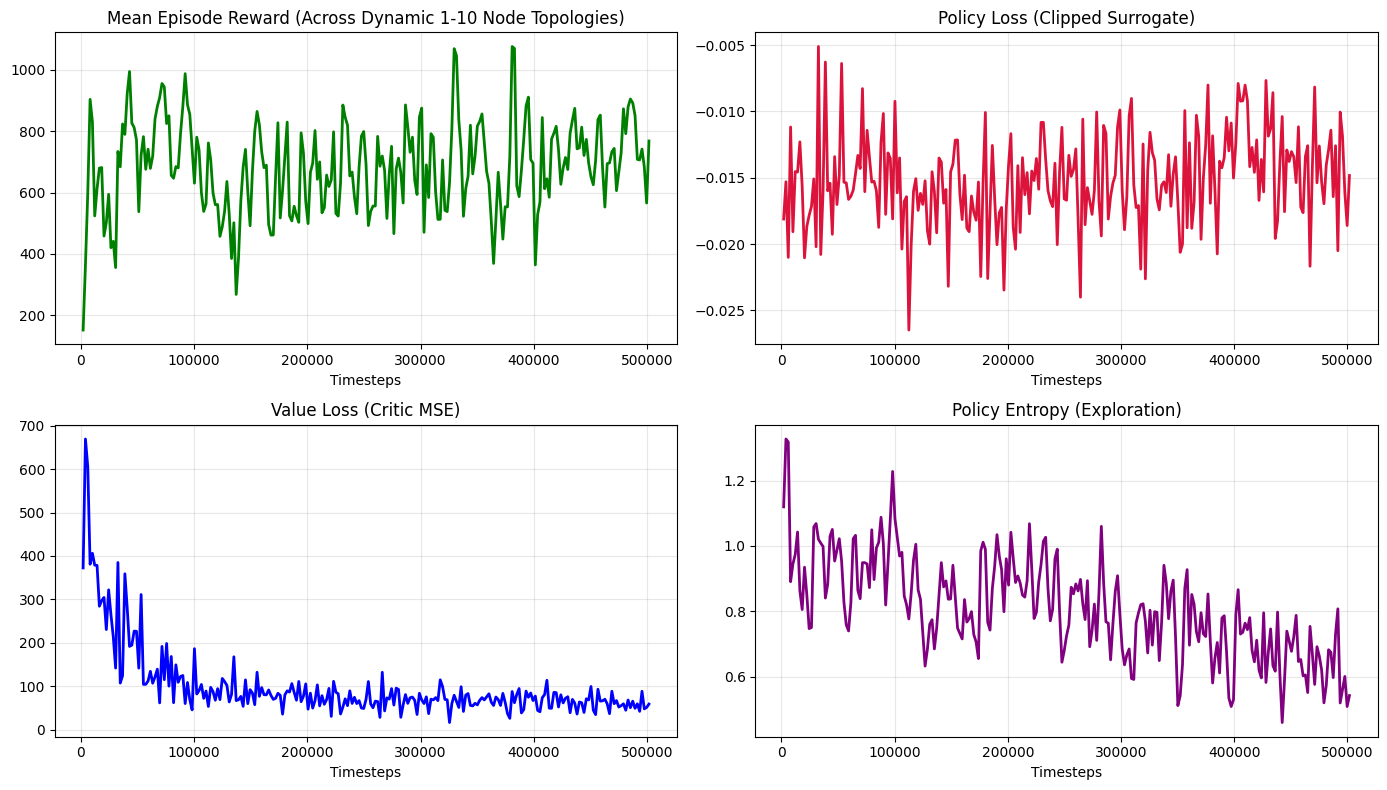

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Mean Episode Reward
axes[0, 0].plot(history["timesteps"], history["mean_reward"], color='green', lw=2)
axes[0, 0].set_title("Mean Episode Reward (Across Dynamic 1-10 Node Topologies)")
axes[0, 0].set_xlabel("Timesteps")
axes[0, 0].grid(True, alpha=0.3)

# 2. Policy Loss (Clipped Surrogate)
axes[0, 1].plot(history["timesteps"], history["policy_loss"], color='crimson', lw=2)
axes[0, 1].set_title("Policy Loss (Clipped Surrogate)")
axes[0, 1].set_xlabel("Timesteps")
axes[0, 1].grid(True, alpha=0.3)

# 3. Value Function Loss (MSE)
axes[1, 0].plot(history["timesteps"], history["value_loss"], color='blue', lw=2)
axes[1, 0].set_title("Value Loss (Critic MSE)")
axes[1, 0].set_xlabel("Timesteps")
axes[1, 0].grid(True, alpha=0.3)

# 4. Policy Entropy
axes[1, 1].plot(history["timesteps"], history["entropy"], color='purple', lw=2)
axes[1, 1].set_title("Policy Entropy (Exploration)")
axes[1, 1].set_xlabel("Timesteps")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()